### 工作進度  
* 新的筆記架構仍待定。初步構想於下：  
  - 第一部分：大盤解盤  
    * 『加權指數』與『櫃買指數』。  
      - 執行mysys.StockAnalysis類別的analysis方法  
        * 針對量化與ＡＩ分析結果加入個人觀點。  
        * 補充老師盤中資訊，來源於[日報](https://mega.nz/folder/a85wHKwK#SA6HACStdXRvMsLd2Ct0tQ)。  
    * 盤前解盤？
      - 參照老師的「[盤前快訊](https://www.facebook.com/kevinyang20180801/posts/pfbid0eHdLcPCzdE2HAcbKD8evNX4BhvyMPQvUkFkt7xEguht8ey3G2JdHtQg55VktSsp3l)」（如果有）。
    * 老師手繪的趨勢線進行量化（[主觀性質的客觀化](https://ithelp.ithome.com.tw/articles/10314112)，參考書籍：[讓證據說話的技術分析(上)](https://www.books.com.tw/products/0010410837)），使用mysys.DrawOnKlineChart函式。  
  - 第二部分：個股解盤  
    * **選股**來源  
      - 老師觀察股  
        * [K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)LINE群組  - 參閱[日報](https://mega.nz/folder/a85wHKwK#SA6HACStdXRvMsLd2Ct0tQ)  
      - 自選觀察股  
        * [股票篩選器：中價位且平均趨向指標(ADX)上升穿越20](https://tw.tradingview.com/screener/FFH7FtPz/)  
    * 個股解盤  
      - 執行mysys.StockAnalysis類別的analysis方法。
      - 老師手繪的趨勢線進行量化（[主觀性質的客觀化](https://ithelp.ithome.com.tw/articles/10314112)，參考書籍：[讓證據說話的技術分析(上)](https://www.books.com.tw/products/0010410837)），使用mysys.DrawOnKlineChart函式。  
      - 補充籌碼面資訊：因為不是所有市場都有籌碼面資訊，因此很難透過AI進行分析，只能人工進行確認。
* 預計8月1日開始使用新的筆記架構，並開新的GitHub倉庫來做發佈。  

#### 引入模組與定義公用函式  
* 這部分在筆記架構中該如何定位？  

In [1]:
import numpy as np
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

#### 建立「解盤」物件    

In [3]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數

解盤內容：


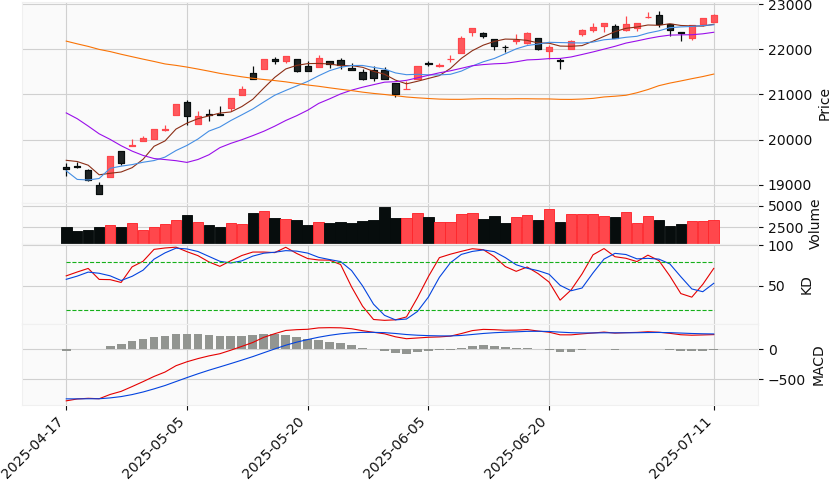

技術分析工具,解盤內容
Ｋ線／Ｋ棒,十字線 : 2025-07-08 吞噬 : 2025-07-09
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 3379.82億元 ，十日均量 ＝ 3346.83億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.25。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-06-30該周在超買區。
整體評價,價格趨勢 目前價格呈現上漲趨勢。K線圖顯示價格持續在5日和10日移動平均線之上，並且20日移動平均線也呈現上升趨勢，顯示短期和中期的多頭趨勢。 價量關係 成交量在近期有增加的趨勢，尤其在價格上漲時伴隨著較高的成交量，顯示出多頭的力量較強，價量配合良好。 支撐與壓力 支撐位可參考20日移動平均線附近，約在22000點左右。壓力位則在近期高點附近，約在23000點。 KD指標解讀 KD指標顯示K線已經突破D線，並且數值在50以上，顯示出多頭的力量正在增強，短期內有進一步上漲的可能。 MACD指標解讀 MACD指標中，DIF線在MACD線之上，且灰色柱體（OSC）為正值，顯示出多頭趨勢持續。 綜合評價 綜合以上分析，目前市場呈現多頭趨勢，短期內有進一步上漲的可能。建議投資者可以考慮在支撐位附近進行買入操作，並在接近壓力位時考慮停利。若價格跌破20日移動平均線，則需謹慎觀察，考慮停損。


In [4]:
stock_analysis(analysis,'TAIEX')

加權指數開低，還在上升楔形中，整理型態，20日線目前仍上揚：  
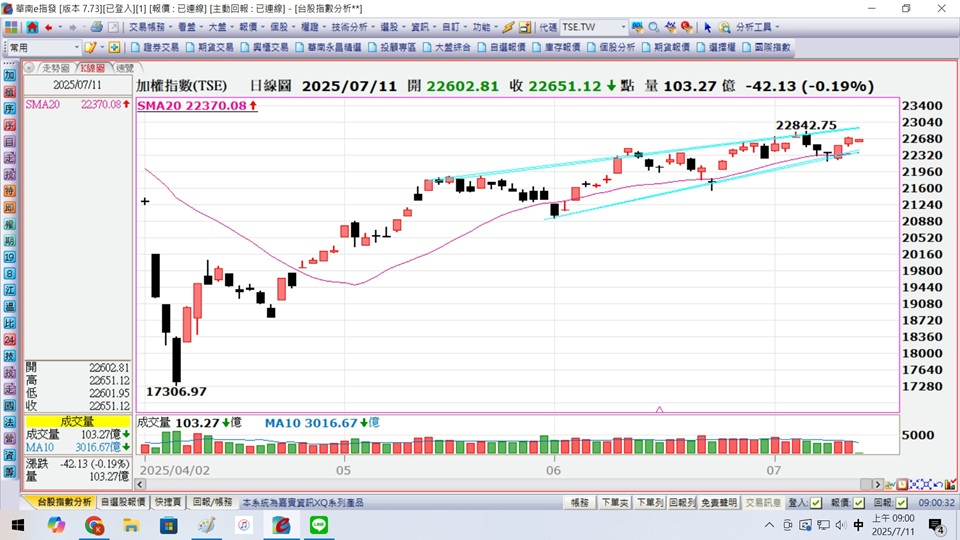  

In [5]:
def line_drawing_callback( range_prices) :
    # 設定楔形壓力線
    resistance_line_start_date  = '2025-05-14'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_x           = [mysys.DateToIndex(range_prices,'2025-05-16'),mysys.DateToIndex(range_prices,'2025-07-04')]
    resistance_line_y           = [range_prices.loc['2025-05-16']['Close'],range_prices.loc['2025-07-04']['Open']]
    slope,intercept             = np.polyfit(resistance_line_x,resistance_line_y,1)
    resistance_line_start_price = slope * mysys.DateToIndex(range_prices,resistance_line_start_date) + intercept
    resistance_line_end_price   = slope * mysys.DateToIndex(range_prices,resistance_line_end_date) + intercept

    # 設定楔形支撐線
    support_line_start_date  = '2025-06-02'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_x           = [mysys.DateToIndex(range_prices,'2025-06-02'),mysys.DateToIndex(range_prices,'2025-07-09')]
    support_line_y           = [range_prices.loc['2025-06-02']['Low'],(range_prices.loc['2025-07-08']['Close'] + range_prices.loc['2025-07-09']['Open'])/2]
    slope,intercept          = np.polyfit(support_line_x,support_line_y,1)
    support_line_start_price = slope * mysys.DateToIndex(range_prices,support_line_start_date) + intercept
    support_line_end_price   = slope * mysys.DateToIndex(range_prices,support_line_end_date) + intercept

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)],
        [(support_line_start_date,support_line_start_price),(support_line_end_date,support_line_end_price)]
    ]

    linewidths=[1.5,1.5]
    
    colors=['xkcd:cyan','xkcd:cyan']

    return seq_of_seq_of_points,linewidths,colors

In [6]:
image = mysys.DrawOnKlineChart('TAIEX','2025-04-02','2025-07-11',line_drawing_callback)

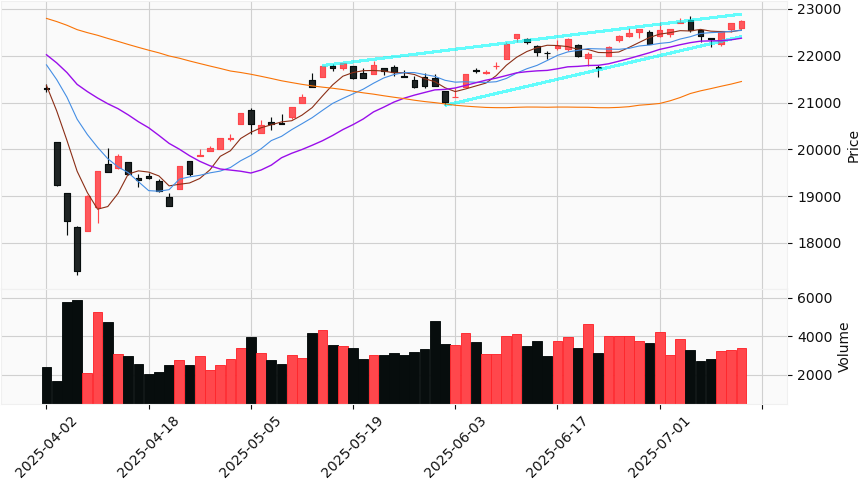

In [7]:
display(image)

* 櫃買指數

解盤內容：


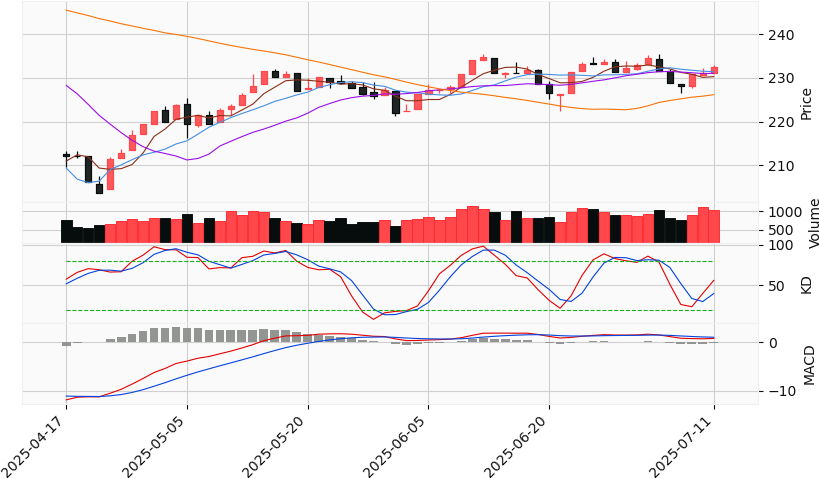

技術分析工具,解盤內容
Ｋ線／Ｋ棒,鎚子線／吊人線 : 2025-07-08 吞噬 : 2025-07-09
Ｋ線圖,中期為中位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 1044.83億元 ，十日均量 ＝ 929.43億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線上揚、10日線下彎，短期盤整；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-02當周死亡交叉。
整體評價,價格趨勢分析 從K線圖來看，近期價格呈現盤整狀態。價格在230至240點之間波動，短期移動平均線（5日和10日）與中期移動平均線（20日和60日）糾結在一起，顯示出市場缺乏明確的方向。 價量關係 成交量在近期有些許增加，但並未顯示出明顯的多頭或空頭趨勢。價格在盤整區間內波動，成交量的變化未能有效推動價格突破。 支撐與壓力判斷 支撐位大約在230點附近，壓力位則在240點左右。價格多次在這兩個位置之間反彈或回檔，顯示出這些位置的有效性。 KD指標解讀 KD指標顯示K線（紅線）在D線（藍線）之上，並且從低位回升，顯示出短期內有反彈的可能性。然而，指標值尚未進入超買區，顯示出上升動能有限。 MACD指標解讀 MACD指標中，DIF線（紅線）與MACD線（藍線）接近零軸，且柱狀體（OSC）顯示出動能不足，表明市場仍處於觀望狀態，缺乏明顯的上升或下降動能。 綜合評價 整體來看，市場目前處於盤整狀態，短期內可能會在230至240點之間波動。若價格能有效突破240點，則可能開啟新的上升趨勢；若跌破230點，則需警惕進一步下跌的風險。建議投資者在此區間內謹慎操作，等待明確的突破信號再行進場。


In [8]:
stock_analysis(analysis,'TPEx')

櫃買指數小箱型整理：  
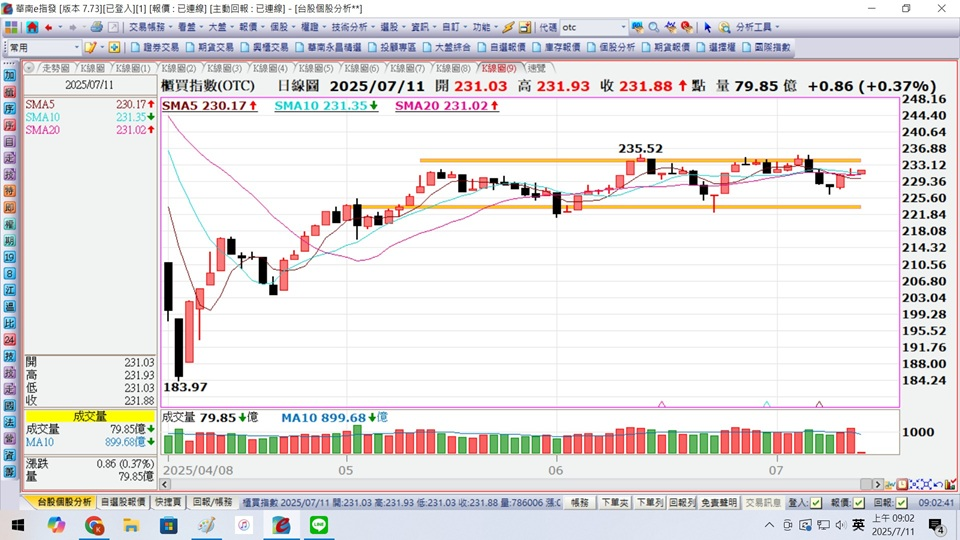  

In [12]:
def line_drawing_callback( range_prices) :
    # 設定箱型壓力線
    resistance_line_start_date  = '2025-05-12'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = (range_prices.loc['2025-06-12']['Open'] + range_prices.loc['2025-06-13']['Open']) / 2 

    # 設定箱型支撐線
    support_line_start_date  = '2025-05-02'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_price       = range_prices.loc['2025-05-09']['Close']

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)],
        [(support_line_start_date,support_line_price),(support_line_end_date,support_line_price)]
    ]

    linewidths=[1.5,1.5]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

In [13]:
image = mysys.DrawOnKlineChart('TPEx','2025-04-08','2025-07-11',line_drawing_callback)

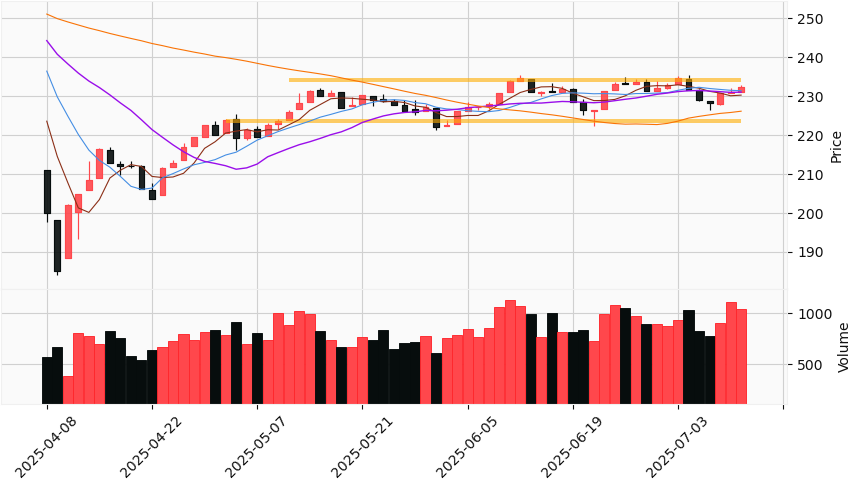

In [14]:
display(image)

### 平日夜間班  
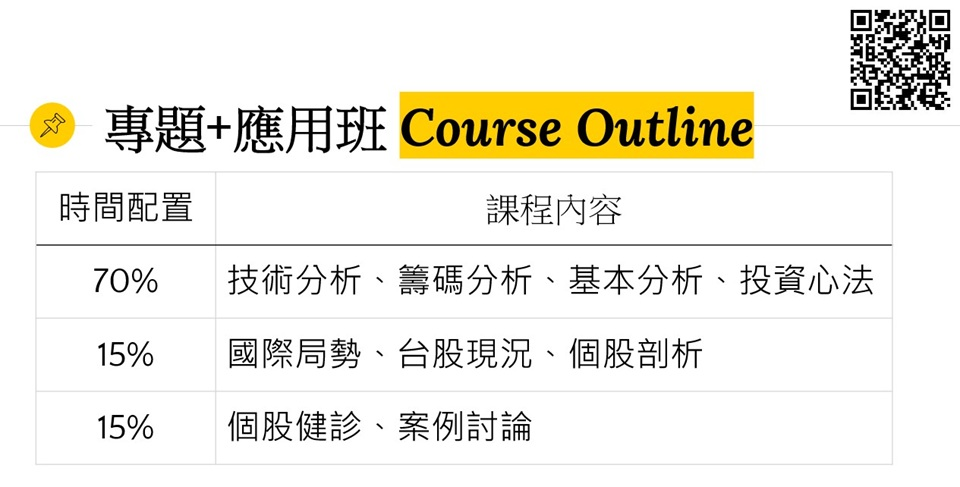  
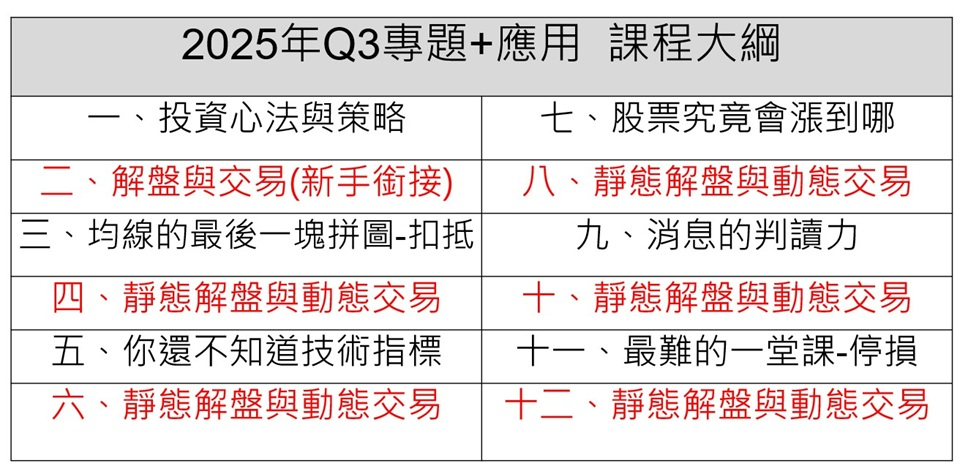  
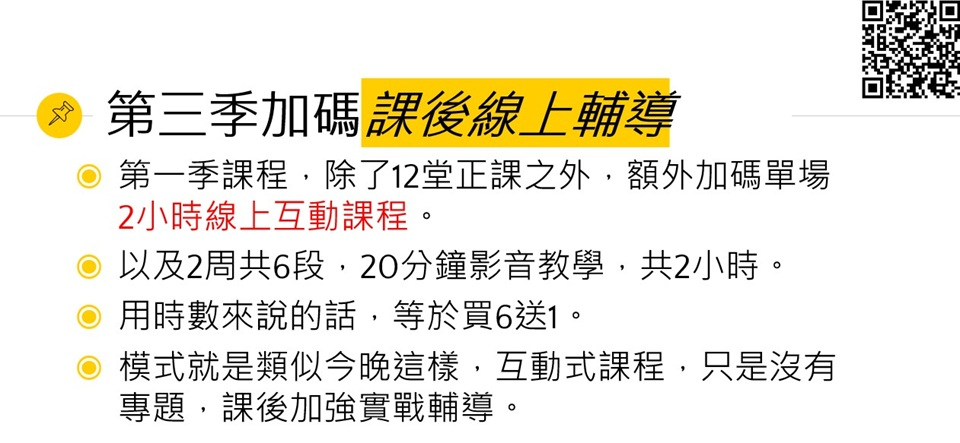  
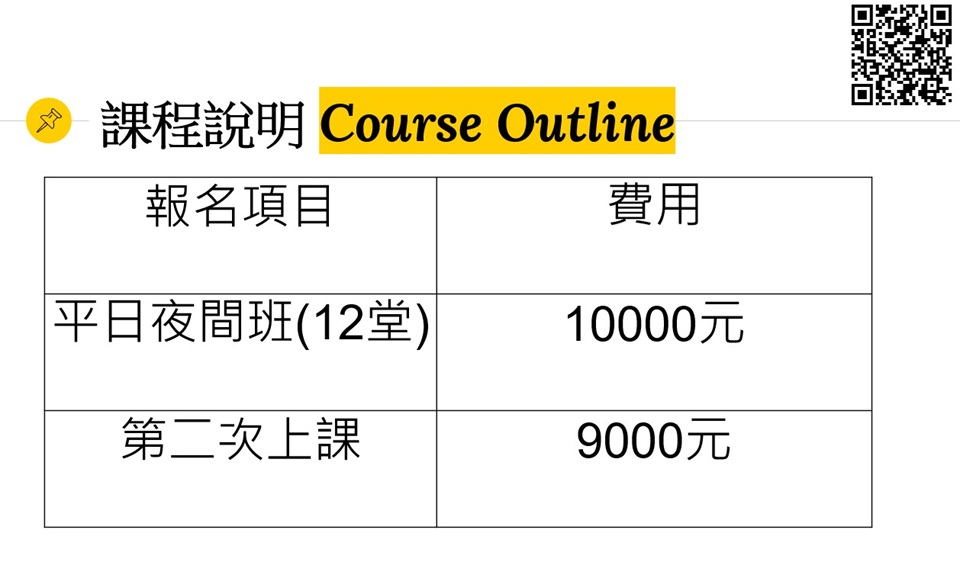  
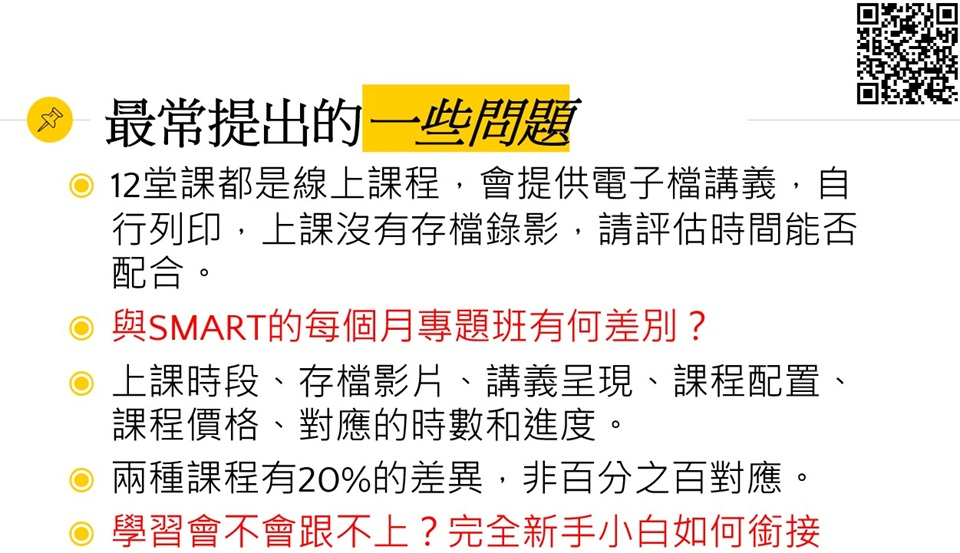  
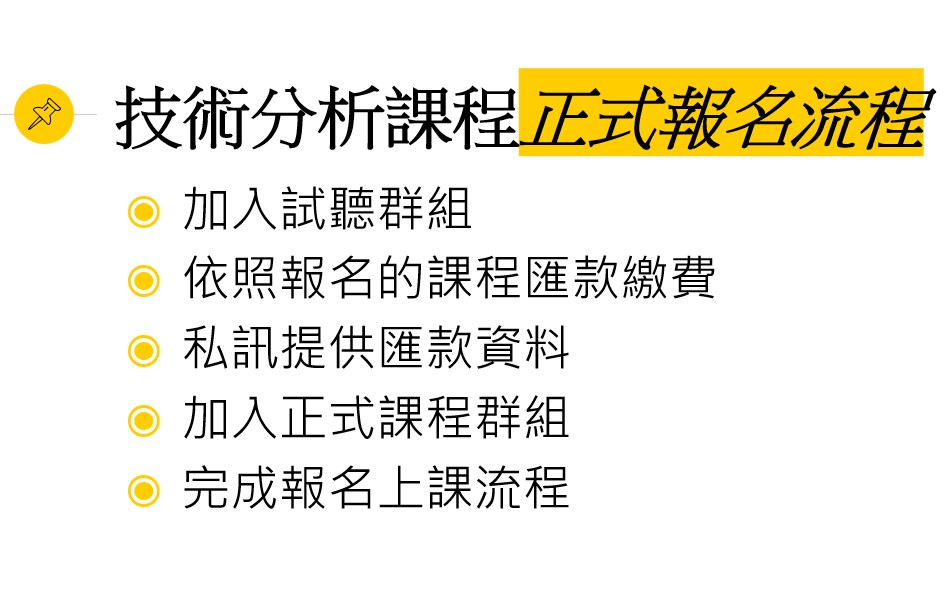  
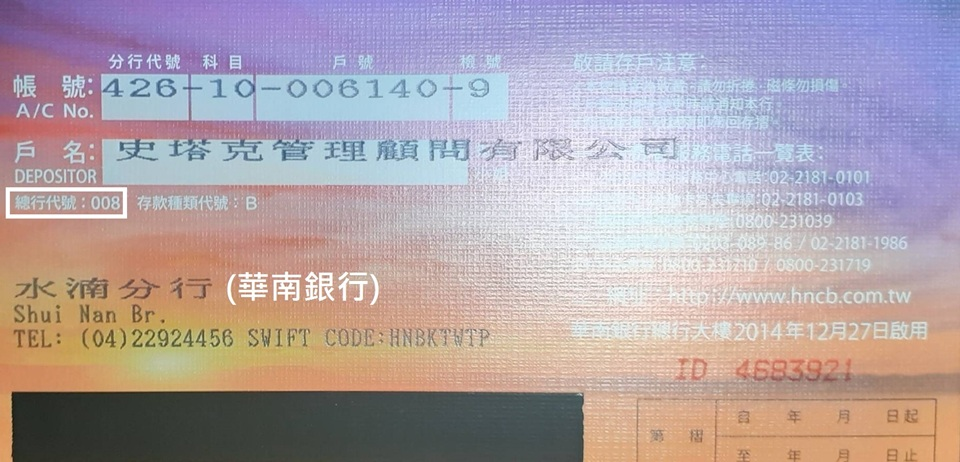  